In [ ]:
#Importación de librerias y dependencias
import torch
import torch.nn as nn
import torch.optim as optim
from src.configuracion import *
from src.dataset import XView2
from src.modelos import SiameseResNet18
from src.entrenamiento import (crear_dataloaders,train_model)
from src.evaluacion import evaluarM
from src.visualizacion import (mostrar_metricas,graficar_loss,graficar_accuracy,graficar_matriz_confusion)

In [2]:
#Verificar configuracion del entorno
print(f"Dispositivo: {DEVICE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Dataset: {DATASET_DIR}")

Dispositivo: cuda
Batch Size: 64
Epochs: 100
Dataset: C:\Users\danie\Downloads\geotiffs


In [ ]:
#Cargar el dataset xView2 con muestreo estratificado
dataset = XView2(DATASET_DIR,sample_size=SAMPLE_SIZE,random_state=RANDOM_STATE)
print(f"Muestras utilizadas: {len(dataset)}")

Escenas encontradas: 11034
Total edificios encontrados: 411357
Total edificios utilizados: 100000
Muestras utilizadas: 100000


In [ ]:
#Crear dataloaders train/val/test y pesos para balanceo
(train_loader,val_loader,test_loader,class_weights) = crear_dataloaders(dataset)
print(f"Train: {len(train_loader)} batches")
print(f"Val: {len(val_loader)} batches")
print(f"Test: {len(test_loader)} batches")

Train: 71738 muestras
Val:   13386 muestras
Test:  14876 muestras
Conteos de entrenamiento: [54780, 6534, 5135, 5289]
Pesos calculados: [0.32739999890327454, 2.744800090789795, 3.4925999641418457, 3.390899896621704]
Train: 1121 batches
Val: 210 batches
Test: 233 batches


In [ ]:
#Instanciar el modelo Siamese ResNet18 en el dispositivo
model = SiameseResNet18().to(DEVICE)
print(model.__class__.__name__)

SiameseResNet18


In [ ]:
#Configurar funcion de perdida con pesos y optimizador Adam
weights = class_weights.to(DEVICE)
print("Pesos utilizados:",weights)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

Pesos utilizados: tensor([0.3274, 2.7448, 3.4926, 3.3909], device='cuda:0')


In [7]:
#Entrenar el modelo con early stopping
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    EPOCHS,
    DEVICE,
    patience=PATIENCE
)

Epoch [1/100] | Train Loss: 0.7717 | Train Acc: 0.7258 | Val Loss: 0.6388 | Val Acc: 0.7721
Epoch [2/100] | Train Loss: 0.5312 | Train Acc: 0.8316 | Val Loss: 0.5835 | Val Acc: 0.8122
Epoch [3/100] | Train Loss: 0.3952 | Train Acc: 0.8676 | Val Loss: 0.6361 | Val Acc: 0.8353
Epoch [4/100] | Train Loss: 0.2703 | Train Acc: 0.8959 | Val Loss: 0.7373 | Val Acc: 0.8411
Epoch [5/100] | Train Loss: 0.1848 | Train Acc: 0.9238 | Val Loss: 0.8085 | Val Acc: 0.8165
Epoch [6/100] | Train Loss: 0.1404 | Train Acc: 0.9383 | Val Loss: 1.0002 | Val Acc: 0.8544
Epoch [7/100] | Train Loss: 0.1108 | Train Acc: 0.9505 | Val Loss: 1.0484 | Val Acc: 0.8422
Epoch [8/100] | Train Loss: 0.1002 | Train Acc: 0.9563 | Val Loss: 1.0343 | Val Acc: 0.8487
Epoch [9/100] | Train Loss: 0.0868 | Train Acc: 0.9598 | Val Loss: 1.1138 | Val Acc: 0.8430
Epoch [10/100] | Train Loss: 0.0796 | Train Acc: 0.9638 | Val Loss: 1.2285 | Val Acc: 0.8555
Epoch [11/100] | Train Loss: 0.0679 | Train Acc: 0.9687 | Val Loss: 1.1827 | Va

In [ ]:
#Guardar los pesos del mejor modelo
modelo_path = (MODELOS_DIR / "siamese_resnet18_xview2.pth")

torch.save(model.state_dict(),modelo_path)

print(f"Mejor modelo guardado en:\n"f"{modelo_path}")

Mejor modelo guardado en:
C:\Users\danie\Downloads\RNyAP-Clasificacion-de-Dano-en-Edificaciones\modelos\siamese_resnet18_xview2.pth


Accuracy          : 0.8092
Balanced Accuracy : 0.7448
Precision weighted: 0.8598
Recall weighted   : 0.8092
F1 weighted       : 0.8265
Precision macro   : 0.6295
Recall macro      : 0.7448
F1 macro          : 0.6728
              precision    recall  f1-score   support

   no-damage     0.9754    0.8425    0.9041     11181
minor-damage     0.3773    0.6045    0.4646      1297
major-damage     0.5482    0.6776    0.6061      1216
   destroyed     0.6170    0.8545    0.7166      1182

    accuracy                         0.8092     14876
   macro avg     0.6295    0.7448    0.6728     14876
weighted avg     0.8598    0.8092    0.8265     14876



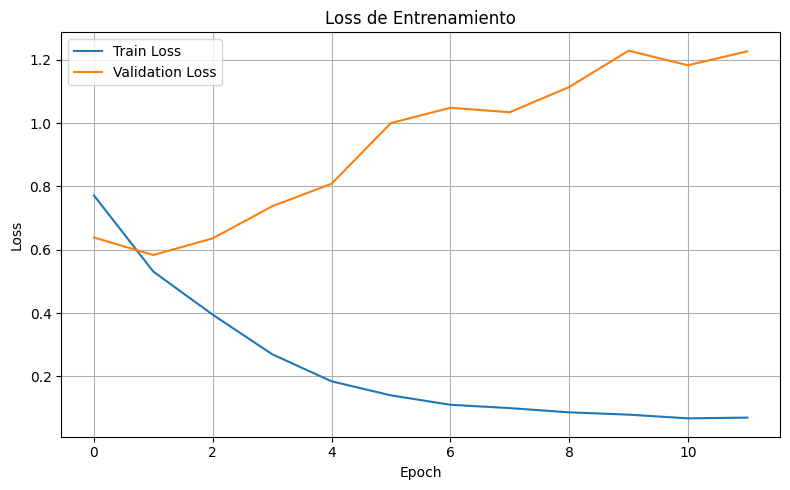

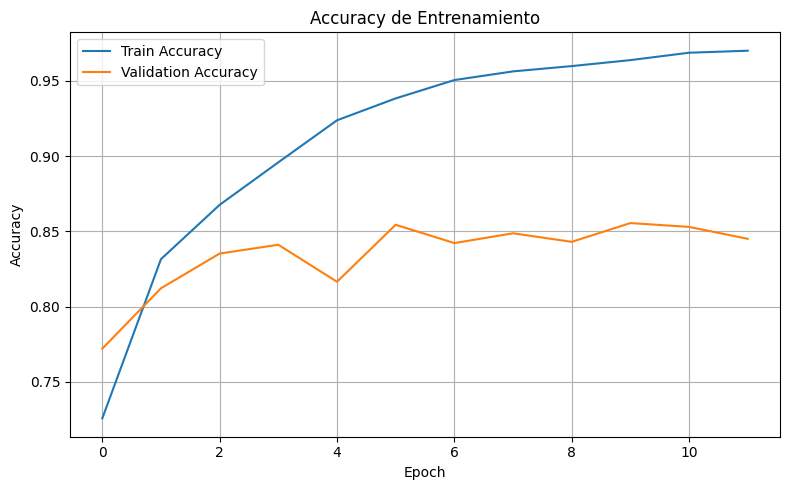

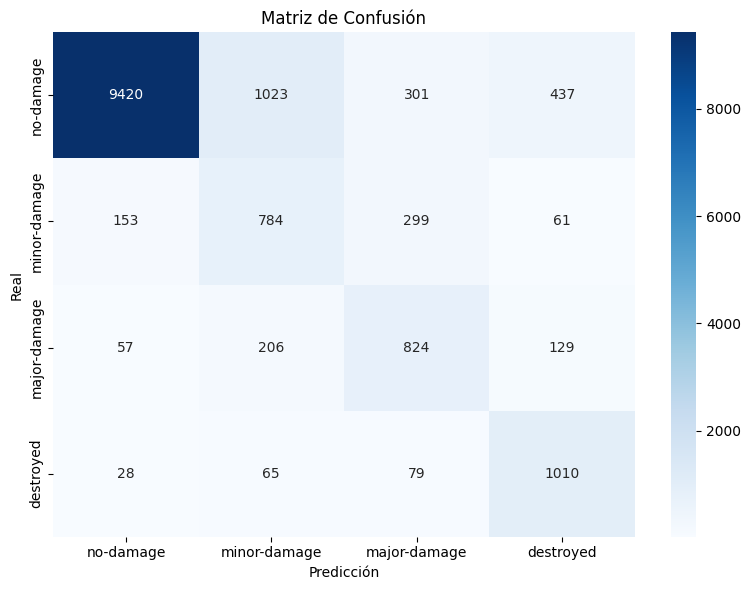

In [ ]:
#Evaluar el modelo y visualizar resultados
resultados = evaluarM(model,test_loader,DEVICE)
mostrar_metricas(resultados)
print(resultados["report"])
graficar_loss(history)
graficar_accuracy(history)
graficar_matriz_confusion(resultados["confusion_matrix"],list(CLASSES.keys()))

Cargando modelo: /home/markusancestro/Documentos/UPIIT-IPN/Redes Neuronales/Proyecto_Clasificador_De_Daño_Imagenes_Satelitales/modelos/GPU_siamese_resnet18_xview2.pth
Modelo cargado en cpu


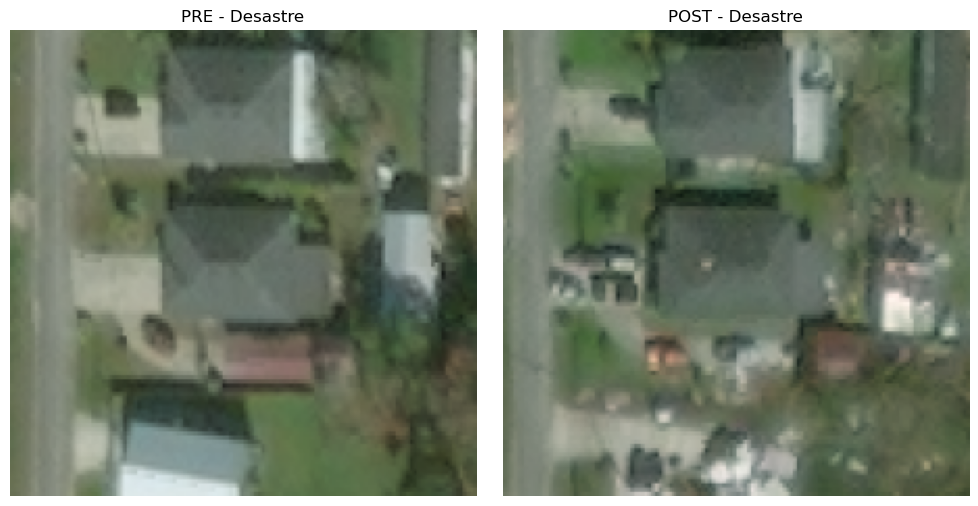

  Indice de muestra: 17142
  Etiqueta real:      minor-damage (1)
  Prediccion:         minor-damage (1)
-------------------------------------------------------
  Probabilidades por clase:
    no-damage           : 0.2650  (26.50%)
    minor-damage        : 0.7098  (70.98%)
    major-damage        : 0.0238  (2.38%)
    destroyed           : 0.0014  (0.14%)


(1, tensor([0.2650, 0.7098, 0.0238, 0.0014]))

In [13]:
#Demostracion visual: prediccion con muestra aleatoria
import random
from src.demo import cargar_modelo, mostrar_prediccion

modelo_demo = cargar_modelo()

idx = random.randint(0, len(dataset) - 1)
mostrar_prediccion(modelo_demo, dataset, idx, DEVICE)